<a href="https://colab.research.google.com/github/avinashtadi/EDA/blob/feature/DAV__E_commerce_Marketing_and_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')
#drive.mount('https://drive.google.com/drive/folders/1--WDP9EmATJkRiAjMmV8p_ZBjwc27I9b?usp=drive_link')

# Define the path to the shared folder in your Google Drive.
# This path will depend on where the shared folder is located within your "Shared with me" section
# after you add it to your drive. You might need to check your Google Drive
# to find the exact path. A common pattern is 'drive/MyDrive/Shared with me/<Folder Name>'.
# Replace '<Folder Name>' with the actual name of the shared folder.
shared_folder_path = 'drive/MyDrive/DAV Business case' # Example path, replace with your actual path
#https://drive.google.com/drive/folders/1--WDP9EmATJkRiAjMmV8p_ZBjwc27I9b?usp=sharing
#https://drive.google.com/drive/folders/1Qt1HfSoTyCKiyDy2frR-hYOT9UvfwGq7?usp=drive_link
# List files in the shared folder to verify
if os.path.exists(shared_folder_path):
    files = os.listdir(shared_folder_path)
    print("Files in the shared folder:", files)

    # Assuming there are CSV files in the folder, read the first one into a DataFrame
    for file in files:
        file_prefix=file.split('.')[0]
        csv_file_path = os.path.join(shared_folder_path, file)
        df_variable=f'{file_prefix}_df'
        if file.endswith('.csv'):
            read_file='pd.read_csv(csv_file_path)'
        if file.endswith('.xlsx'):
            read_file='pd.read_excel(csv_file_path)'
        else:
            print("Unsupported file type")
        if file.endswith('.csv') or file.endswith('.xlsx'):
            print("loading..."+df_variable)
            try:
                exec(f'{df_variable}= {read_file}')
                print("\nDataFrame loaded from:", df_variable)
                exec(f'{df_variable}.head()') # Display the first few rows of the DataFrame
            except Exception as e:
                print(f"Error reading {file}: {e}")

else:
    print("Shared folder path not found. Please check the 'shared_folder_path' variable and ensure the shared folder is added to your Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in the shared folder: ['Online_Sales.csv', 'Marketing_Spend.csv', 'Discount_Coupon.csv', 'CustomersData.xlsx', 'Tax_amount.xlsx', 'Dataset Description.docx']
Unsupported file type
loading...Online_Sales_df

DataFrame loaded from: Online_Sales_df
Unsupported file type
loading...Marketing_Spend_df

DataFrame loaded from: Marketing_Spend_df
Unsupported file type
loading...Discount_Coupon_df

DataFrame loaded from: Discount_Coupon_df
loading...CustomersData_df

DataFrame loaded from: CustomersData_df
loading...Tax_amount_df

DataFrame loaded from: Tax_amount_df
Unsupported file type


In [3]:
Online_Sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           52924 non-null  int64  
 1   Transaction_ID       52924 non-null  int64  
 2   Transaction_Date     52924 non-null  object 
 3   Product_SKU          52924 non-null  object 
 4   Product_Description  52924 non-null  object 
 5   Product_Category     52924 non-null  object 
 6   Quantity             52924 non-null  int64  
 7   Avg_Price            52924 non-null  float64
 8   Delivery_Charges     52924 non-null  float64
 9   Coupon_Status        52924 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 4.0+ MB


###1) Identify the months with the highest and lowest acquisition rates. What strategies could be implemented to address the fluctuations and ensure consistent growth throughout the year?


Acquisition Rate: This is a metric that measures the efficiency of a business in acquiring new customers over a specific period. It is typically calculated as the number of new customers acquired during a period divided by the total number of potential customers, leads, or visitors during that same period, often expressed as a percentage. A higher acquisition rate indicates that a business is effectively attracting new customers [1, 2].

Formula (common variations):

(Number of New Customers / Total Potential Customers or Leads) * 100
(Number of New Customers / Total Website Visitors) * 100
(Number of New Customers / Number of Prospects Contacted) * 100
The specific denominator used depends on the business model and what is being measured (e.g., website visitors, marketing leads, sales prospects).

Retention Rate: This is a metric that measures the percentage of existing customers that a business retains over a specific period. It indicates the loyalty of the customer base. A high retention rate indicates that a business has a loyal customer base [2].

Formula:

([(Number of Customers at End of Period - Number of New Customers Acquired During Period) / Number of Customers at Start of Period] * 100)
Alternatively, some businesses calculate churn rate (the opposite of retention rate) and subtract it from 100%

In [4]:
 Online_Sales_df['Transaction_Date'] = pd.to_datetime(Online_Sales_df['Transaction_Date'])
 Online_Sales_df['Transaction_Month'] = Online_Sales_df['Transaction_Date'].dt.month
 monthly_transactions_df=pd.DataFrame()
 monthly_transactions_df=(Online_Sales_df.groupby('Transaction_Month').size().reset_index())
 monthly_transactions_df.columns = ['Transaction_Month','Total_Transactions']
 monthly_transactions_df.head()



,Transaction_Month,Total_Transactions
0,1,4063
1,2,3284
2,3,4346
3,4,4150
4,5,4572


In [5]:
customer_date_ranges = Online_Sales_df.groupby('CustomerID').agg(
        min_transaction_date=('Transaction_Date', 'min'),
        max_transaction_date=('Transaction_Date', 'max'),
        min_transaction_id=('Transaction_ID', 'min'),
        max_transaction_id=('Transaction_ID', 'max')
    ).reset_index()

customer_date_ranges['max_month']=(customer_date_ranges['max_transaction_date']).dt.month
customer_date_ranges['min_month']=(customer_date_ranges['min_transaction_date']).dt.month

new_customer_monthly_df=customer_date_ranges.groupby('min_month').size().reset_index()
new_customer_monthly_df.columns = ['Transaction_Month','New_Transactions']
new_customer_monthly_df.head()
customer_date_ranges.head()

,CustomerID,min_transaction_date,max_transaction_date,min_transaction_id,max_transaction_id,max_month,min_month
0,12346,2019-09-15,2019-09-15,38223,38223,9,9
1,12347,2019-03-24,2019-11-02,23979,42397,11,3
2,12348,2019-06-22,2019-10-19,31048,41110,10,6
3,12350,2019-12-14,2019-12-14,46870,46882,12,12
4,12356,2019-09-15,2019-09-15,38208,38222,9,9


In [6]:
monthly_stats_df = pd.merge(
    monthly_transactions_df,
    new_customer_monthly_df,
    on='Transaction_Month',
    how='outer'
)

monthly_stats_df['Acquisition_Rate'] = (monthly_stats_df['New_Transactions'] / monthly_stats_df['Total_Transactions']) * 100
acquisition_stats_df=monthly_stats_df.agg({'Acquisition_Rate': ['min', 'max']}).reset_index()
min_month=monthly_stats_df[monthly_stats_df['Acquisition_Rate']==acquisition_stats_df[acquisition_stats_df['index'] == 'min']['Acquisition_Rate'].iloc[0]]['Transaction_Month'].iloc[0]
max_month=monthly_stats_df[monthly_stats_df['Acquisition_Rate']==acquisition_stats_df[acquisition_stats_df['index'] == 'max']['Acquisition_Rate'].iloc[0]]['Transaction_Month'].iloc[0]

print(f'The highest acquisition month {max_month}')
print(f'The Lowest acquisition month {min_month}')


The highest acquisition month 1
The Lowest acquisition month 11


In [7]:
monthly_stats_df.head(13)

,Transaction_Month,Total_Transactions,New_Transactions,Acquisition_Rate
0,1,4063,215,5.291656
1,2,3284,96,2.923264
2,3,4346,177,4.072711
3,4,4150,163,3.927711
4,5,4572,112,2.449694
5,6,4193,137,3.267350
6,7,5251,94,1.790135
7,8,6150,135,2.195122
8,9,4288,78,1.819030
9,10,4164,87,2.089337


## Analyze the data to determine if certain months consistently show higher or lower acquisition rates. How can the company capitalize on high-performing months and improve performance during slower periods?

Design targeted marketing campaigns specifically for those lower acquisition months. These campaigns could involve special promotions, discounts, or unique product/service bundles to incentivize new customers. For example, if you see a dip in acquisition in the summer months, you might run a "Summer Special" campaign. Conversely, during peak months, you might focus on maximizing conversions from the increased traffic.

The highest acquisition month 1
The Lowest acquisition month 11
July - Dec has seen the rate dropping below mean.



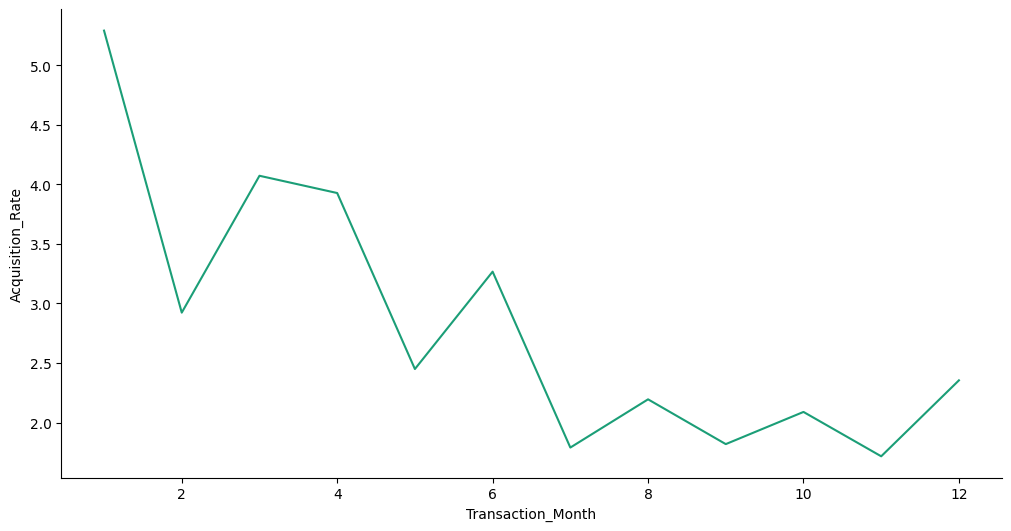

In [8]:
# @title Transaction_Month vs Acquisition_Rate

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Transaction_Month']
  ys = series['Acquisition_Rate']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = monthly_stats_df.sort_values('Transaction_Month', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Transaction_Month')
_ = plt.ylabel('Acquisition_Rate')

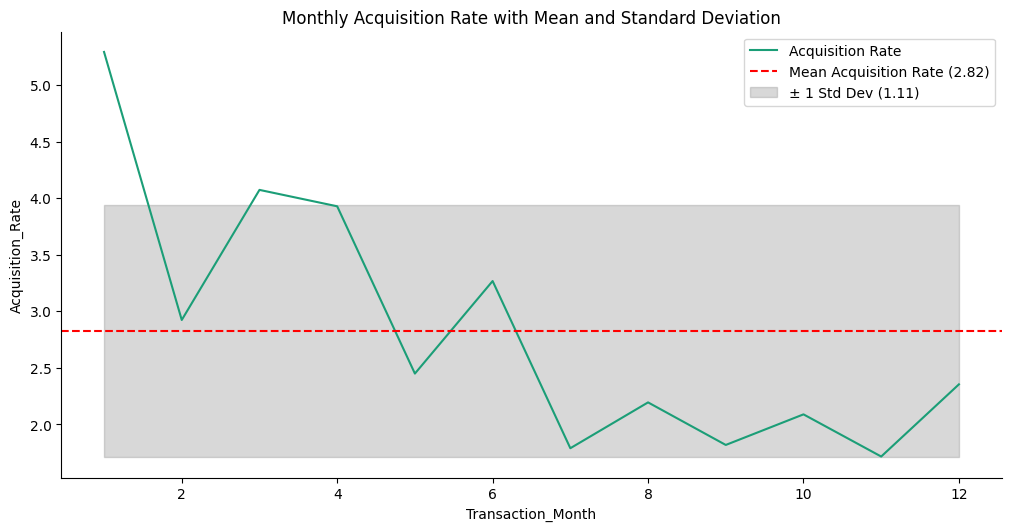

In [9]:
# @title Transaction_Month vs Acquisition_Rate

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported if not already

def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Transaction_Month']
  ys = series['Acquisition_Rate']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = monthly_stats_df.sort_values('Transaction_Month', ascending=True)
_plot_series(df_sorted, 'Acquisition Rate') # Add a label for the existing line

# Calculate the mean and standard deviation of the Acquisition Rate across all months
mean_acquisition_rate = monthly_stats_df['Acquisition_Rate'].mean()
std_acquisition_rate = monthly_stats_df['Acquisition_Rate'].std()

# Add a horizontal line for the mean
ax.axhline(mean_acquisition_rate, color='red', linestyle='--', label=f'Mean Acquisition Rate ({mean_acquisition_rate:.2f})')

# Add shaded regions for one standard deviation above and below the mean
# Use fill_between to create the shaded area
ax.fill_between(df_sorted['Transaction_Month'],
                mean_acquisition_rate - std_acquisition_rate,
                mean_acquisition_rate + std_acquisition_rate,
                color='gray', alpha=0.3, label=f'± 1 Std Dev ({std_acquisition_rate:.2f})')


sns.despine(fig=fig, ax=ax)
plt.xlabel('Transaction_Month')
_ = plt.ylabel('Acquisition_Rate')
plt.title('Monthly Acquisition Rate with Mean and Standard Deviation') # Add a title
plt.legend() # Add a legend to show the labels for the lines and shaded area
plt.show() # Explicitly show the plot

In [10]:
# Ensure Transaction_Date is in datetime format and Transaction_Month is extracted
Online_Sales_df['Transaction_Date'] = pd.to_datetime(Online_Sales_df['Transaction_Date'])
Online_Sales_df['Transaction_Month'] = Online_Sales_df['Transaction_Date'].dt.month
Online_Sales_df['Transaction_Year'] = Online_Sales_df['Transaction_Date'].dt.year # Add year for accurate period definition

# Combine year and month for a unique period identifier
Online_Sales_df['Transaction_Period'] = Online_Sales_df['Transaction_Date'].dt.to_period('M')

# Get unique customers per period
customers_per_period = Online_Sales_df.groupby('Transaction_Period')['CustomerID'].unique().reset_index()
customers_per_period['CustomerID'] = customers_per_period['CustomerID'].apply(list) # Ensure the unique CustomerIDs are lists

# Determine the first transaction month for each customer (already have this in customer_date_ranges)
customer_date_ranges['first_transaction_period'] = customer_date_ranges['min_transaction_date'].dt.to_period('M')

# Create a list of all unique periods in your data, sorted
all_periods = sorted(Online_Sales_df['Transaction_Period'].unique())
print(all_periods)
retention_data = []

for i in range(1, len(all_periods)):
    current_period = all_periods[i]
    previous_period = all_periods[i-1]

    # Get customers who were active in the previous period
    customers_start_period = customers_per_period[customers_per_period['Transaction_Period'] == previous_period]['CustomerID'].iloc[0] if previous_period in customers_per_period['Transaction_Period'].values else []

    # Get customers who were active in the current period
    customers_end_period = customers_per_period[customers_per_period['Transaction_Period'] == current_period]['CustomerID'].iloc[0] if current_period in customers_per_period['Transaction_Period'].values else []

    # Get new customers in the current period
    # We can use the customer_date_ranges to find customers whose first transaction was in the current period
    new_customers_in_period = customer_date_ranges[customer_date_ranges['first_transaction_period'] == current_period]['CustomerID'].tolist()


    # Calculate retained customers: customers from the start period who are also in the end period
    retained_customers = len(set(customers_start_period) & set(customers_end_period))

    # Calculate customers at the start of the period (excluding new customers from the previous period)
    # This is simply the number of unique customers in the previous period
    num_customers_start_period = len(customers_start_period)

    # Calculate customers at the end of the period
    num_customers_end_period = len(customers_end_period)

    # Number of new customers acquired during the period (already calculated)
    num_new_customers_in_period = len(new_customers_in_period)


    # Calculate Retention Rate for the transition from previous_period to current_period
    if num_customers_start_period > 0:
         # Using the standard formula: ((End Customers - New Customers) / Start Customers) * 100
         retention_rate = ((num_customers_end_period - num_new_customers_in_period) / num_customers_start_period) * 100
    else:
        retention_rate = 0 # No customers to retain from the previous period

    retention_data.append({'Period': current_period,
                           'Customers_Start_Period': num_customers_start_period,
                           'Customers_End_Period': num_customers_end_period,
                           'New_Customers_in_Period': num_new_customers_in_period,
                           'Retained_Customers': retained_customers,
                           'Retention_Rate': retention_rate})

# Create a DataFrame for monthly retention
monthly_retention_df = pd.DataFrame(retention_data)

print(monthly_retention_df.head(15))

[Period('2019-01', 'M'), Period('2019-02', 'M'), Period('2019-03', 'M'), Period('2019-04', 'M'), Period('2019-05', 'M'), Period('2019-06', 'M'), Period('2019-07', 'M'), Period('2019-08', 'M'), Period('2019-09', 'M'), Period('2019-10', 'M'), Period('2019-11', 'M'), Period('2019-12', 'M')]
     Period  Customers_Start_Period  Customers_End_Period  \
0   2019-02                     215                   109   
1   2019-03                     109                   208   
2   2019-04                     208                   224   
3   2019-05                     224                   200   
4   2019-06                     200                   259   
5   2019-07                     259                   236   
6   2019-08                     236                   300   
7   2019-09                     300                   193   
8   2019-10                     193                   210   
9   2019-11                     210                   188   
10  2019-12                     188     

## Identify periods with the strongest and weakest retention rates. What strategies could be implemented to improve retention during weaker months?


In [25]:
retention_stats_df=monthly_retention_df.agg({'Retention_Rate': ['min', 'max']}).reset_index()
min_month=monthly_retention_df[monthly_retention_df['Retention_Rate']==retention_stats_df[retention_stats_df['index'] == 'min']['Retention_Rate'].iloc[0]]['Period'].iloc[0]
max_month=monthly_retention_df[monthly_retention_df['Retention_Rate']==retention_stats_df[retention_stats_df['index'] == 'max']['Retention_Rate'].iloc[0]]['Period'].iloc[0]


print(f'The Lowest retention month {min_month}')
print(f'The highest retention month {max_month}')

The Lowest retention month 2019-02
The highest retention month 2019-08


In [21]:
monthly_retention_df

,Period,Customers_Start_Period,Customers_End_Period,New_Customers_in_Period,Retained_Customers,Retention_Rate
0,2019-02,215,109,96,13,6.046512
1,2019-03,109,208,177,11,28.440367
2,2019-04,208,224,163,24,29.326923
3,2019-05,224,200,112,25,39.285714
4,2019-06,200,259,137,37,61.000000
5,2019-07,259,236,94,58,54.826255
6,2019-08,236,300,135,65,69.915254
7,2019-09,300,193,78,44,38.333333
8,2019-10,193,210,87,29,63.730570
9,2019-11,210,188,68,31,57.142857


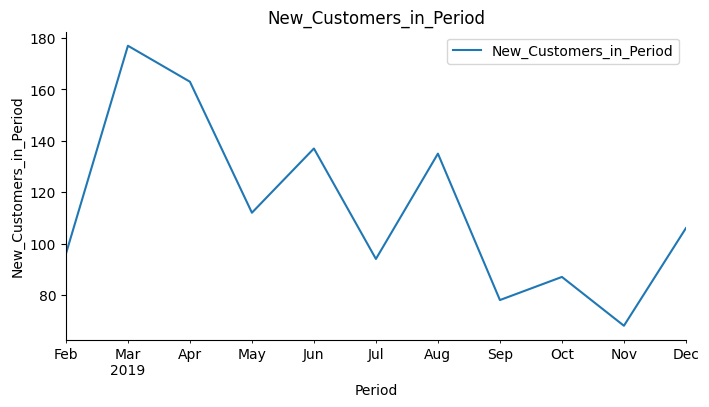

In [29]:
# @title New_Customers_in_Period
from matplotlib import pyplot as plt
monthly_retention_df.plot(x='Period', y='New_Customers_in_Period', kind='line', figsize=(8, 4), title='New_Customers_in_Period')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel('Period')
plt.ylabel('New_Customers_in_Period')
plt.show()

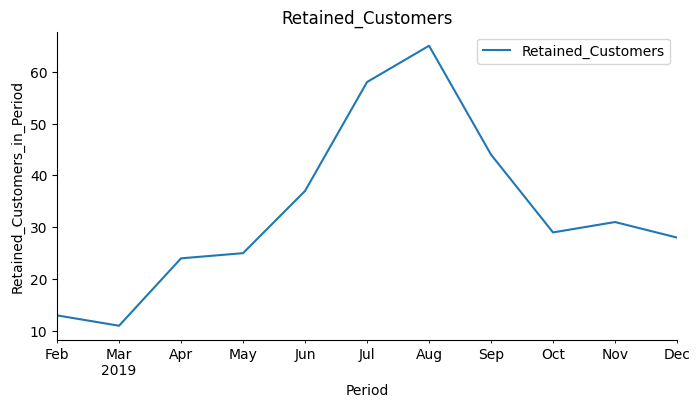

In [30]:
# @title Retained_Customers

from matplotlib import pyplot as plt
monthly_retention_df.plot(x='Period', y='Retained_Customers', kind='line', figsize=(8, 4), title='Retained_Customers')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel('Period')
plt.ylabel('Retained_Customers_in_Period')
plt.show()

In [35]:
Marketing_Spend_df['Date']=pd.to_datetime(Marketing_Spend_df['Date'])

In [37]:
Marketing_Spend_df['Period']=Marketing_Spend_df['Date'].dt.to_period('M')

In [62]:
Periodic_Market_Spen_df=Marketing_Spend_df.groupby('Period').agg(Total_Offline_Spend=('Offline_Spend','sum'),Total_Online_Spend=('Online_Spend','sum')).reset_index()

Periodic_Market_Spen_df['Total_cumulative_spend']=Periodic_Market_Spen_df['Total_Offline_Spend']+Periodic_Market_Spen_df['Total_Online_Spend']
Periodic_Market_Spen_df.head()

,Period,Total_Offline_Spend,Total_Online_Spend,Total_cumulative_spend
0,2019-01,96600,58328.95,154928.95
1,2019-02,81300,55807.92,137107.92
2,2019-03,73500,48750.09,122250.09
3,2019-04,96000,61026.83,157026.83
4,2019-05,65500,52759.64,118259.64


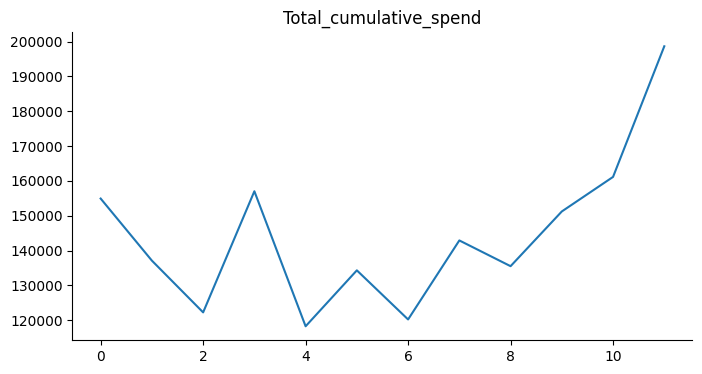

In [63]:
# @title Total_cumulative_spend

from matplotlib import pyplot as plt
Periodic_Market_Spen_df['Total_cumulative_spend'].plot(kind='line', figsize=(8, 4), title='Total_cumulative_spend')
plt.gca().spines[['top', 'right']].set_visible(False)

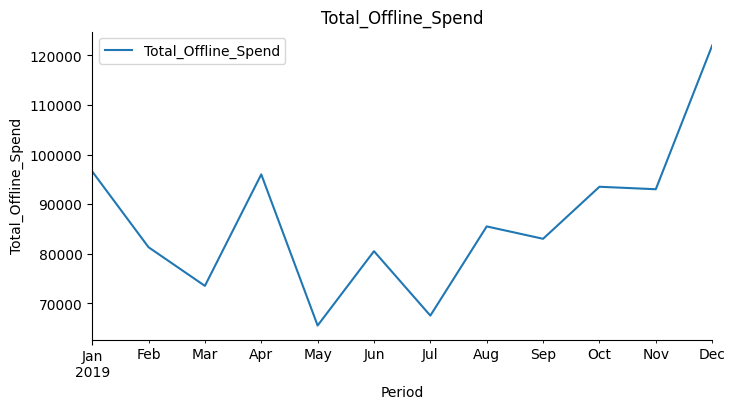

In [55]:
# @title Total_Offline_Spend
from matplotlib import pyplot as plt
Periodic_Market_Spen_df.plot(x='Period', y='Total_Offline_Spend', kind='line', figsize=(8, 4), title='Total_Offline_Spend')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel('Period')
plt.ylabel('Total_Offline_Spend')
plt.show()


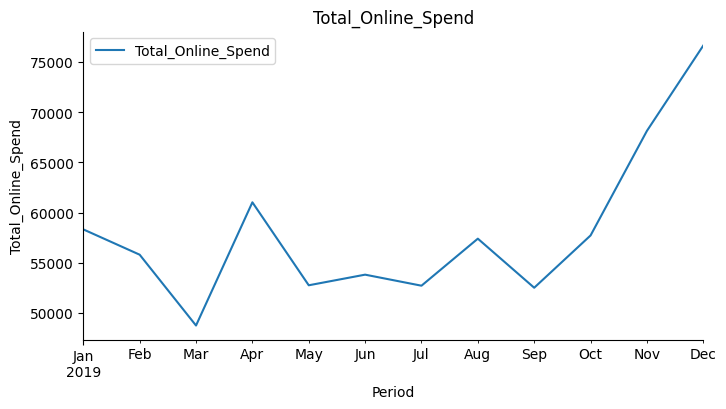

In [64]:
# @title Total_Offline_Spend
from matplotlib import pyplot as plt
Periodic_Market_Spen_df.plot(x='Period', y='Total_Online_Spend', kind='line', figsize=(8, 4), title='Total_Online_Spend')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel('Period')
plt.ylabel('Total_Online_Spend')
plt.show()

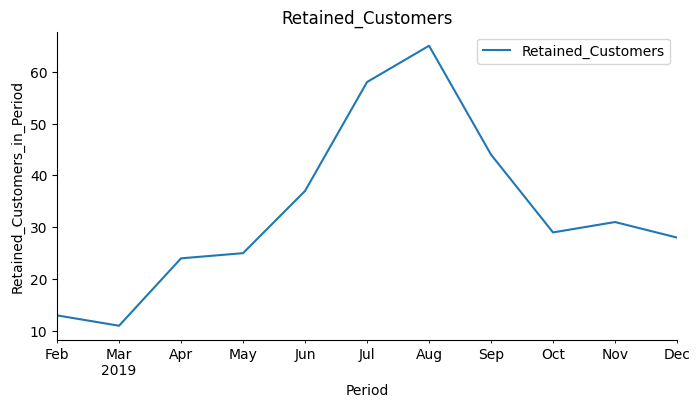

In [53]:
# @title Total_Online_Spend

from matplotlib import pyplot as plt
monthly_retention_df.plot(x='Period', y='Retained_Customers', kind='line', figsize=(8, 4), title='Retained_Customers')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel('Period')
plt.ylabel('Retained_Customers_in_Period')
plt.show()


In [70]:
Discount_Coupon_df.groupby('Month').agg(Total_Discount_Coupon=('Discount_pct','sum')).reset_index()

,Month,Total_Discount_Coupon
0,Apr,170
1,Aug,340
2,Dec,510
3,Feb,340
4,Jan,170
5,Jul,170
6,Jun,510
7,Mar,510
8,May,340
9,Nov,340


In [69]:
Discount_Coupon_df.head()

,Month,Product_Category,Coupon_Code,Discount_pct
0,Jan,Apparel,SALE10,10
1,Feb,Apparel,SALE20,20
2,Mar,Apparel,SALE30,30
3,Jan,Nest-USA,ELEC10,10
4,Feb,Nest-USA,ELEC20,20


In [72]:
Online_Sales_df.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Transaction_Month,Transaction_Year,Transaction_Period
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,2019,2019-01
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,2019,2019-01
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,1,2019,2019-01
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,1,2019,2019-01
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,1,2019,2019-01
